In [2]:
import sys
sys.path.insert(0, '../../mitsuba3/build/python')

import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

import drjit as dr
import mitsuba as mi

mi.set_variant('cuda_ad_rgb')

## Define original sphere to map

In [21]:
res = 100
theta = dr.linspace(mi.Float, 0, dr.pi/2 + 0.1*dr.pi, res)
phi = dr.linspace(mi.Float, 0, 2 * dr.pi, res)
theta, phi = dr.meshgrid(theta, phi)
st, ct = dr.sincos(theta)
sp, cp = dr.sincos(phi)

wi = mi.Vector3f(st * cp, st * sp, ct)
dr.eval(wi)

True

## Test a warp

In [22]:
def pdf_cosine_hemisphere(wi):
    return dr.inv_pi * dr.maximum(0.0, mi.Frame3f.cos_theta(wi))

def pdf_uniform_hemisphere_pdf(wi):
    return dr.inv_two_pi & (mi.Frame3f.cos_theta(wi) > 0.0)

def pdf(pdf_func, wi, mat):
    inv_mat = dr.rcp(mat)
    im_wi = inv_mat @ wi
    norm = dr.norm(im_wi)
    return dr.abs(dr.det(inv_mat)) * pdf_func(im_wi / norm) / (norm * norm * norm)

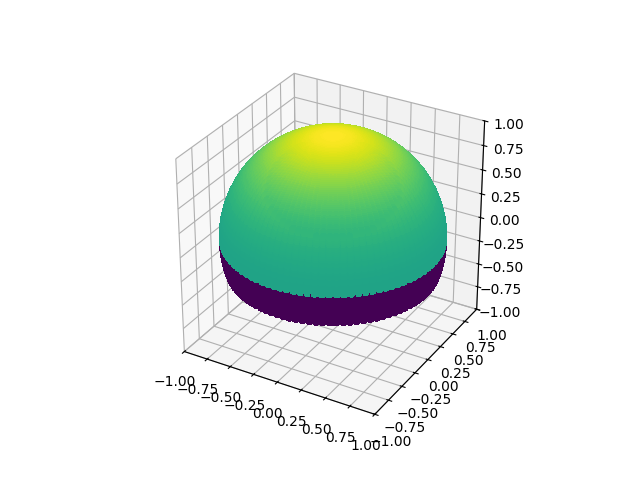

In [23]:
mat = mi.Matrix3f(
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 1.2]
)
pdf_out = pdf(pdf_uniform_hemisphere_pdf, wi, mat)

dr.eval(pdf_out)

# Plotting
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(wi.x, wi.y, wi.z, c=pdf_out, antialiased=False, depthshade=False)
ax.set_box_aspect([1,1,1])  # Equal aspect ratio
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)
plt.show()


## Setup optimization

Loading tensor data from "../../mitsuba3/resources/data/sunsky/output/sunsky_datasets.bin" .. (540.0 KiB, 7 fields)
[[-1.07417, -0.165494, 1.82403, 2.16928, -3.41016, 1.03082, 0.133675, 0.584439, 0.703435],
 [-1.08064, -0.17883, 1.39011, 1.24634, -4.84241, 0.870527, 0.100654, 1.71226, 0.682799],
 [-1.07335, -0.2012, 0.790745, 0.0585924, -1.35328, 0.610736, 0.0585557, 2.80727, 0.668802]]


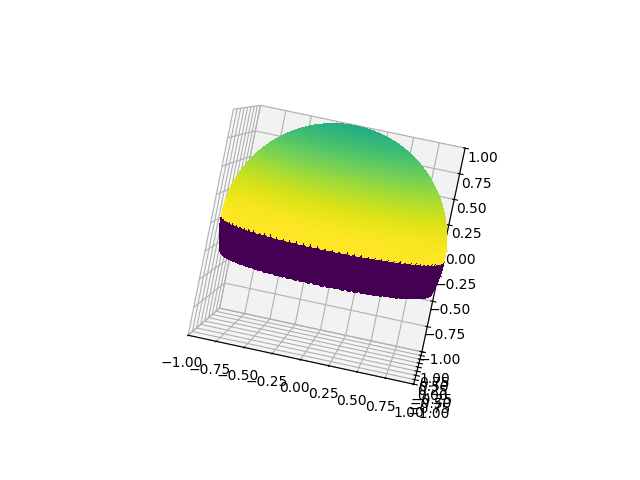

In [ ]:
from vizsky_contrib import load_tensors, interpolate_dataset, f_extra

turb_res = 10
sun_eta_res = 30

class SkyFitter:
    def __init__(self, sky_rad_dataset, sky_params_dataset, turb, sun_eta, sun_phi=dr.pi/2):
        self.sky_rad = interpolate_dataset(sky_rad_dataset, 0.5, turb, sun_eta)
        self.sky_params = interpolate_dataset(sky_params_dataset, 0.5, turb, sun_eta)
        self.turb_pos = turb - 1
        self.sun_eta_pos = (dr.rad2deg(sun_eta) - 2) / 3
        
        sun_theta = dr.pi / 2 - sun_eta
        st, ct = dr.sincos(sun_theta)
        sp, cp = dr.sincos(sun_phi)
        self.sun_dir = mi.Vector3f(st * cp, st * sp, ct)

        quad_pts, quad_wts = mi.quad.gauss_legendre(200)
        dr.print(self.sky_params)
        integrand = (1 + f_extra(self.sky_params, quad_pts, 0)) * self.sky_rad[..., dr.newaxis] * quad_wts
        integrand = mi.luminance(mi.Color3f(integrand)) * mi.MI_CIE_D65_NORMALIZATION

        dr.eval(self.sky_rad, self.sky_params, self.sun_dir)

    def fit(self, weights, dirs):
        cos_theta, gamma = mi.Frame3f.cos_theta(dirs), dr.unit_angle(dirs, self.sun_dir)
        sky_radiance = (1 + f_extra(self.sky_params, cos_theta, gamma)) * self.sky_rad[..., dr.newaxis] & (cos_theta >= 0)
        lum = mi.luminance(mi.Color3f(sky_radiance)) * mi.MI_CIE_D65_NORMALIZATION

        weights_1 = dr.take_interp(weights, self.turb_pos)
        weights_2 = dr.take_interp(weights_1, self.sun_eta_pos)

        param = dr.gather(mi.Float, weights_2.array, mi.UInt32(0))
        inv_mat = mi.Matrix3f(
            [1.0,  0.0, 0.0],
            [0.0,  1.0, 0.0],
            [0.0,  0.0, dr.rcp(param)]
        )
        im_wi = inv_mat @ wi
        norm = dr.norm(im_wi)
        approx_pdf = dr.abs(dr.det(inv_mat)) * pdf_uniform_hemisphere_pdf(im_wi / norm) / (norm * norm * norm)
        return approx_pdf
    
    def luminance(self, dirs):
        cos_theta, gamma = mi.Frame3f.cos_theta(dirs), dr.unit_angle(dirs, self.sun_dir)
        sky_radiance = (1 + f_extra(self.sky_params, cos_theta, gamma)) * self.sky_rad[..., dr.newaxis] & (cos_theta >= 0)
        
        return mi.luminance(mi.Color3f(sky_radiance)) * mi.MI_CIE_D65_NORMALIZATION

    


sky_rad_dataset, sky_params_dataset = load_tensors('../../mitsuba3/resources/data/sunsky/output/sunsky_datasets.bin')

rng = dr.rng(42)
weights = rng.normal(mi.TensorXf, (turb_res, sun_eta_res, 1))
sky_fitter = SkyFitter(sky_rad_dataset, sky_params_dataset, turb=3.0, sun_eta=dr.pi/4)
err = sky_fitter.fit(weights, wi)

ax.scatter(wi.x, wi.y, wi.z, c=err, antialiased=False, depthshade=False)
ax.set_box_aspect([1,1,1])  # Equal aspect ratio
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)
plt.show()